In [28]:
import numpy as np
from collections import defaultdict
import pickle
import matplotlib.pyplot as plt
import prettypyplot as pplt
import msmhelper as mh
# --
import utils
import importlib
importlib.reload(utils)
from utils import mean_first_passage_time, stationary_distribution
# --
import _013_PRC_clustering
importlib.reload(_013_PRC_clustering)
from _013_PRC_clustering import PcaCluster
# --
import _007_EXP_model_validation
import importlib
importlib.reload(_007_EXP_model_validation)
from _007_EXP_model_validation import get_md_empiricial_distribution


In [4]:
# todo standard deviation estimator for transition matrix (see "Markov or Not Markov – This Should Be a Question")

def normalize_rows(counts_matrix):
    transition_matrix = np.zeros_like(counts_matrix)
    n_states = counts_matrix.shape[0]
    for i in range(n_states):
        row_sum = np.sum(counts_matrix[i, :])
        if row_sum == 0:
            print(f"Row sum is 0, setting row {i} to 0    :( ")
            transition_matrix[i, :] = 0
            continue
        transition_matrix[i, :] = counts_matrix[i, :] / row_sum
    return transition_matrix

def generate_counts_matrix(data):    
    # Initialize transition counts
    counts = defaultdict(lambda: defaultdict(int))
    
    # Count transitions
    for sequence in data:
        for t in range(len(sequence) - 1):
            current_state = sequence[t]
            next_state = sequence[t + 1]
            counts[current_state][next_state] += 1
    return counts

def generate_transition_matrix(data, n_clusters, init_1 = False, add_to_diag = 0):
    """
    Generate a transition matrix from an array of categorical time series.
    
    Parameters:
    -----------
    data : array-like
        Array of shape [n_diffusers, t] containing categorical data, categories denoted by integers.
        categories should probably be sorted somehow (center of mass in fg space?). 
    n_clusters : int
        
    Returns:
    --------
    transition_matrix : numpy.ndarray
        Matrix of transition probabilities
    states : list
        List of unique states (categories)
    """
    counts = generate_counts_matrix(data)
    
    # Create transition matrix
    if init_1: transition_matrix = np.ones((n_clusters, n_clusters)) * 0.001
    else: transition_matrix = np.zeros((n_clusters, n_clusters))
    transition_matrix += add_to_diag * np.eye(n_clusters)
    
    # Fill transition matrix with probabilities
    for i in range(n_clusters):
        for j in range(n_clusters):
            transition_matrix[i, j] += counts[i][j]
    transition_matrix = normalize_rows(transition_matrix)
    
    return transition_matrix

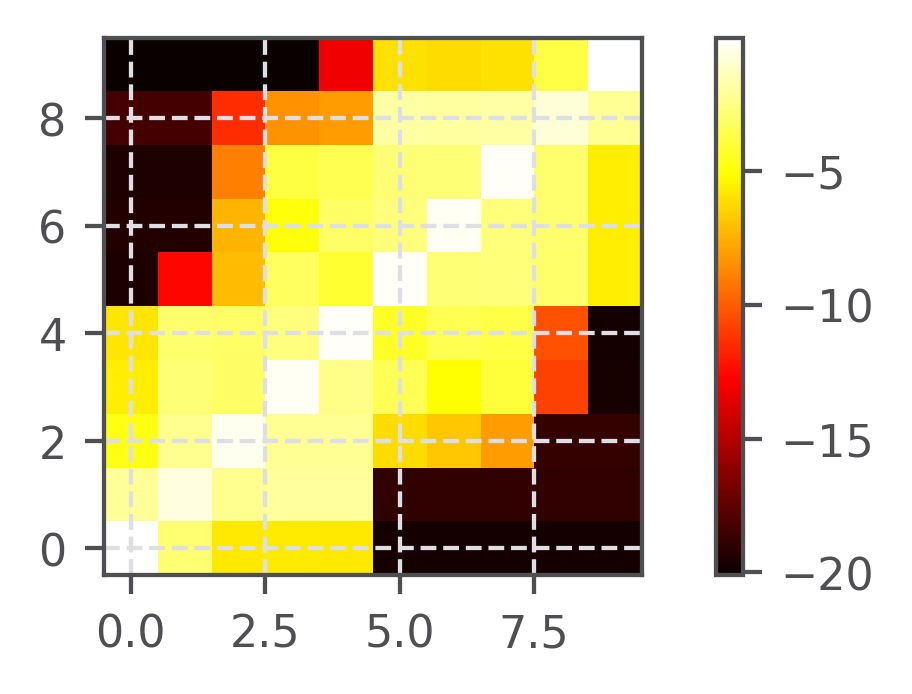

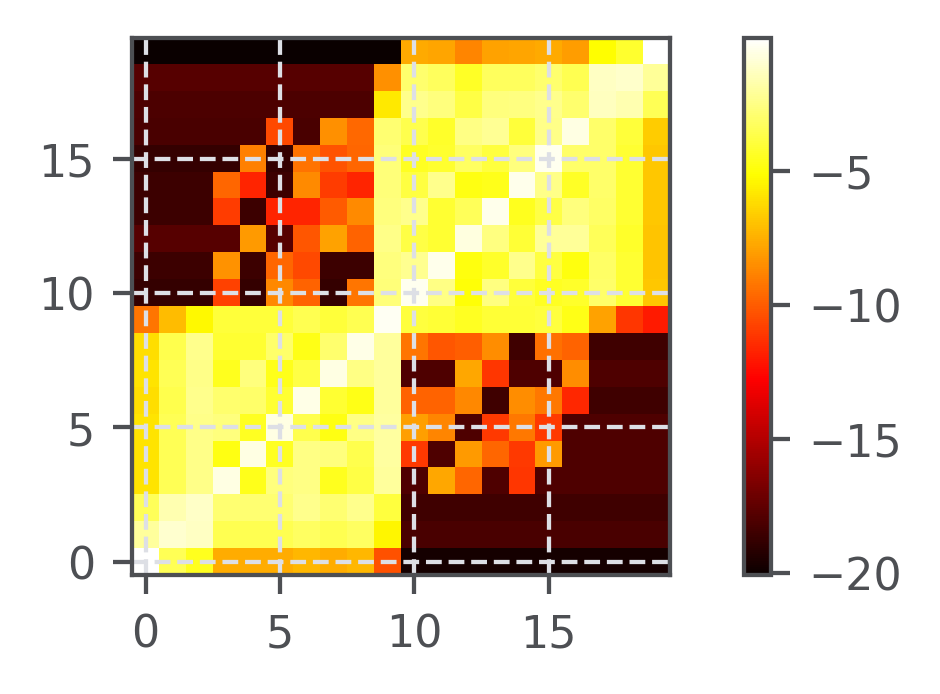

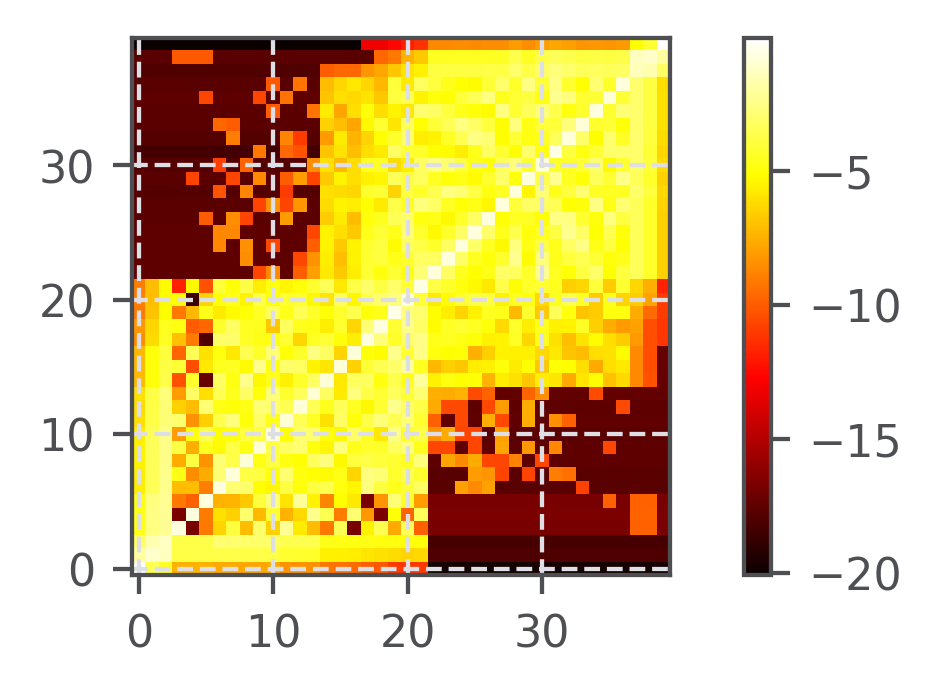

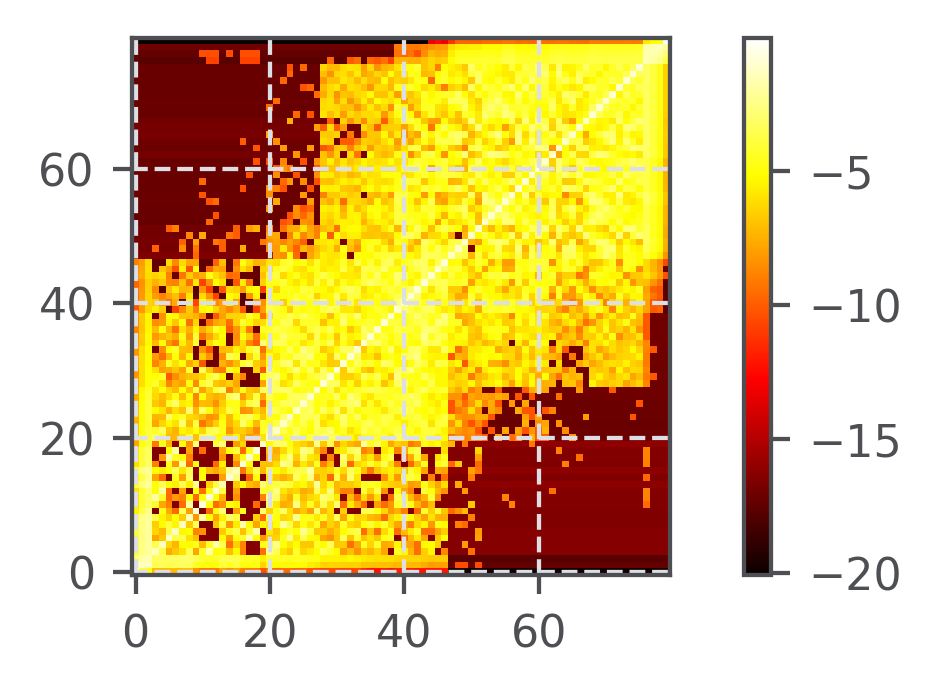

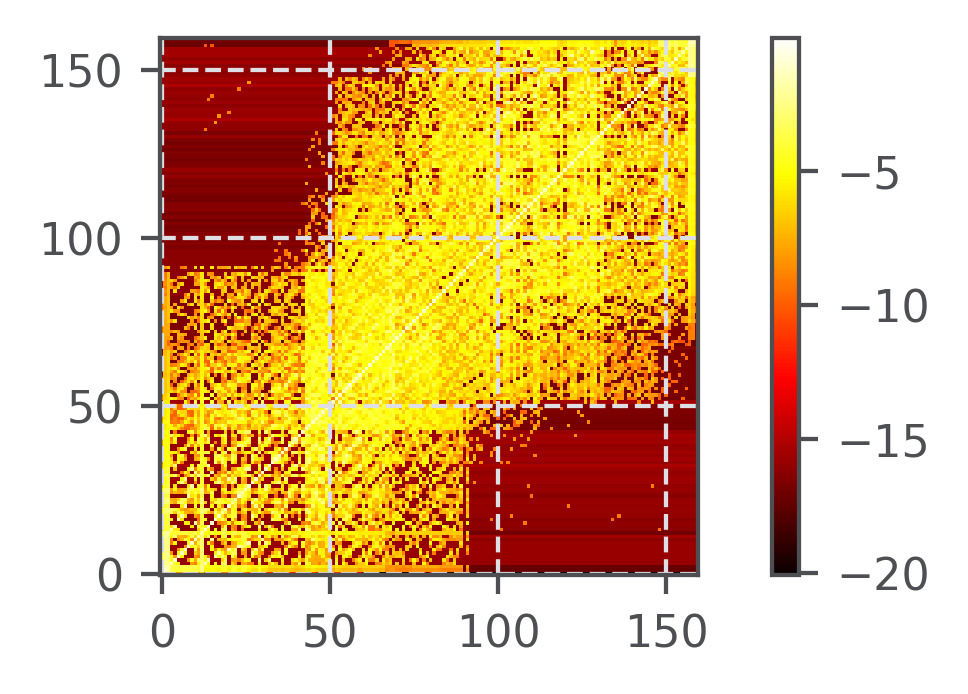

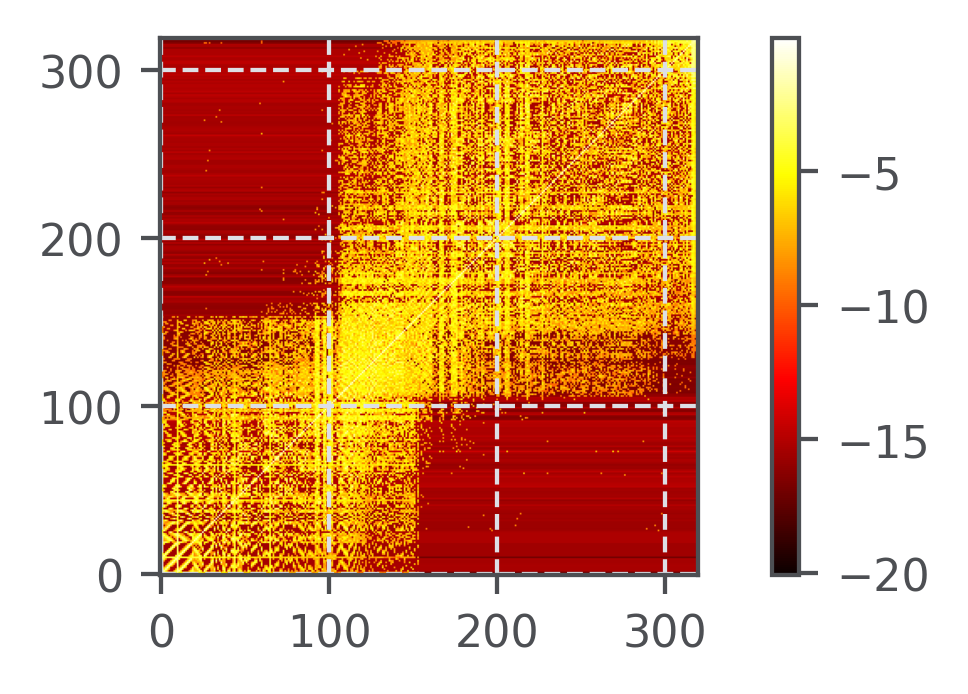

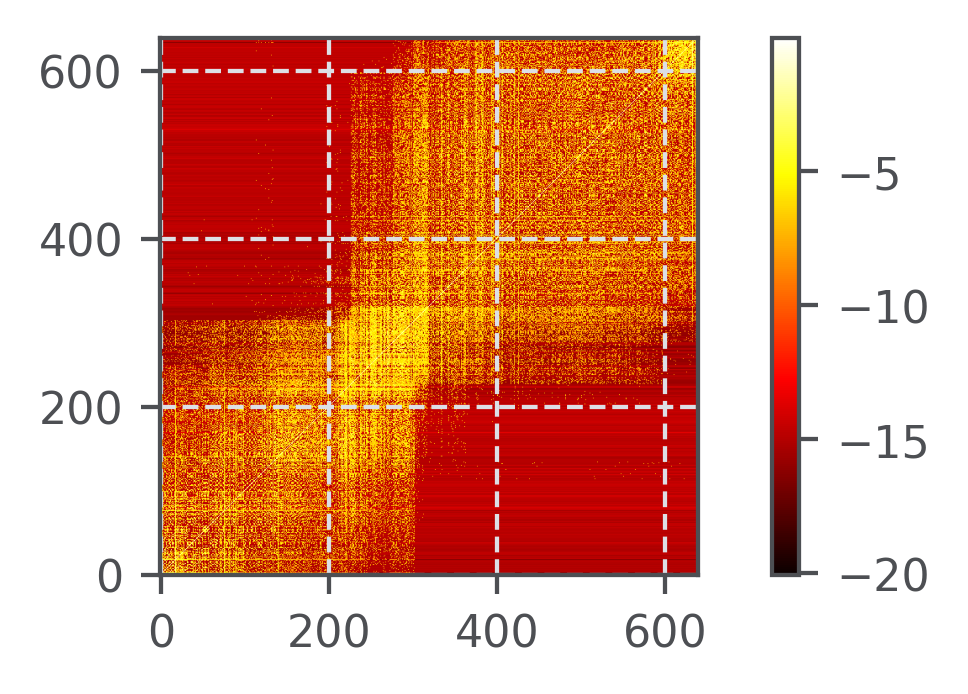

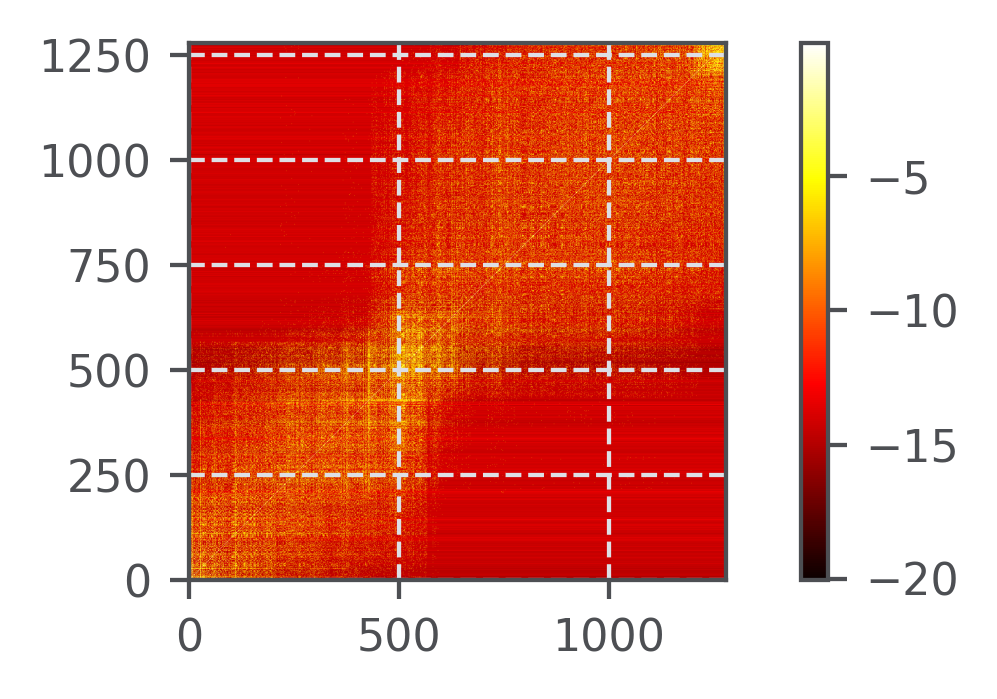

In [5]:
for n_clusters in [10, 20, 40, 80, 160, 320, 640, 1280]:
    with open(f"data/clustered/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
        clustered_data = pickle.load(f)
    transition_matrix = generate_transition_matrix(clustered_data, n_clusters, init_1 = True)
    with open(f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/cluster-kmeans/74pca-{n_clusters}clusters.pickle", "wb") as f:
        pickle.dump(transition_matrix, f)
    plt.imshow(np.log(transition_matrix), cmap='hot')
    plt.colorbar()
    plt.show()
    
# for n_clusters in [10, 20, 40, 80, 160, 320]:
#     with open(f"data/clustered/interactions-150-180-100ns-3k-hist-bisectingkmeans-{n_clusters}clusters.pickle", "rb") as f:
#         clustered_data = pickle.load(f)
#     transition_matrix = generate_transition_matrix(clustered_data, n_clusters, init_1 = True)
#     with open(f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/cluster-bisectingkmeans/{n_clusters}clusters.pickle", "wb") as f:
#         pickle.dump(transition_matrix, f)
#     plt.imshow(np.log(transition_matrix), cmap='hot')
#     plt.colorbar()
#     plt.show()

In [7]:
def mm_permiability(tm, states, bottom_states=None, top_states=None):
    
    # Simulate
    mfpt = mean_first_passage_time(tm, states, bottom_states, top_states) # units: 1000ns
    mfpt_s = 1e-6 * mfpt # units: s
    transport_events_per_s = 1 / mfpt_s # units: 1/s
    concentration_uM = 50/250 # approx, single molecule
    
    # units : n_events / s / uM / NPC 
    perm = transport_events_per_s / concentration_uM
    
    return perm

variant = "kmeans"

for n_clusters in [10, 20, 40, 80, 160, 320, 640, 1280]:
    with open(f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/cluster-{variant}/74pca-{n_clusters}clusters.pickle", "rb") as f:
        tm = pickle.load(f)
    with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-74pca-{variant}-{n_clusters}clusters.pickle", "rb") as f:
        pca_cluster = pickle.load(f)
    centers = pca_cluster.get_inverse_centers()
    bottom_indices = np.where(centers[:, 0] > 0.9)[0]
    top_indices = np.where(centers[:, -1] > 0.9)[0]
    # print(bottom_indices, top_indices)
    
    
    premiability = mm_permiability(tm, [f"{i}" for i in range(n_clusters)], bottom_states=list(bottom_indices), top_states=list(top_indices))
    print(f"permiability for {n_clusters} clusters: {premiability} n / s / uM / NPC ")

permiability for 10 clusters: 20270.43873444648 n / s / uM / NPC 
permiability for 20 clusters: 13629.252695435422 n / s / uM / NPC 
permiability for 40 clusters: 15764.244015889073 n / s / uM / NPC 
permiability for 80 clusters: 11896.265051787599 n / s / uM / NPC 
permiability for 160 clusters: 11799.433204249104 n / s / uM / NPC 
permiability for 320 clusters: 7777.2870416503865 n / s / uM / NPC 
permiability for 640 clusters: 7663.687362968722 n / s / uM / NPC 
permiability for 1280 clusters: 9417.591401699174 n / s / uM / NPC 


/cs/labs/ravehb/roi.eliasian/miniconda3/envs/general_notebooks/lib/python3.10/site-packages/msmhelper/msm/timescales.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  impl_timescales[idx] = _implied_timescales(


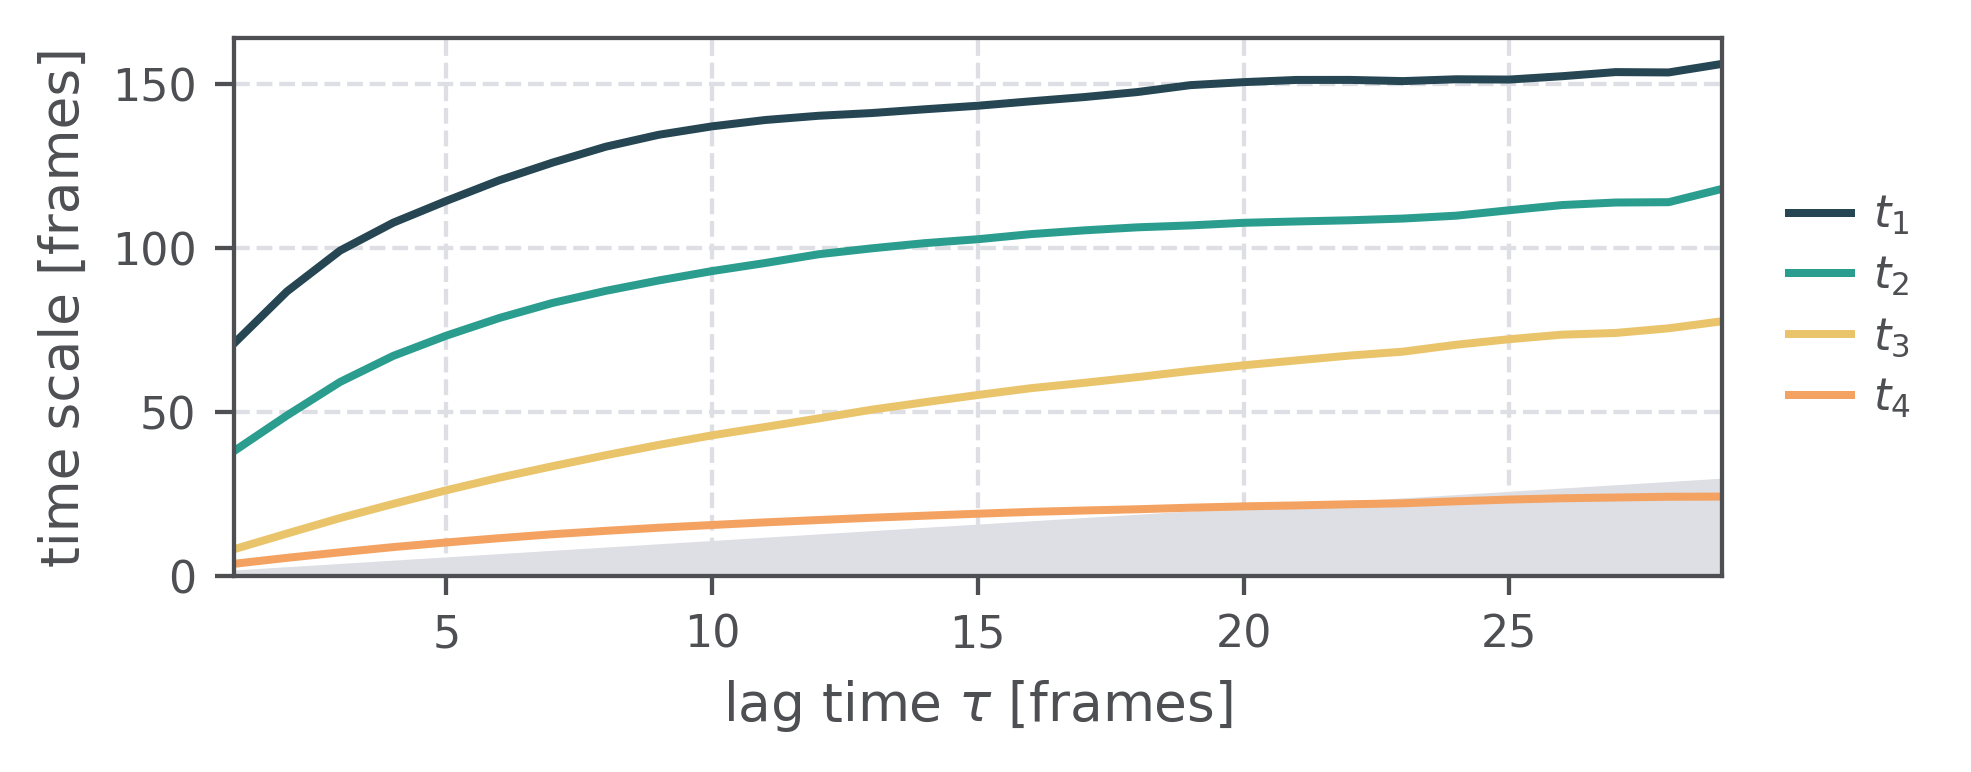

In [2]:
# Validate convergence with implied timescales
# https://moldyn.github.io/msmhelper/tutorials/msm/#implied-timescales
with open(f"data/clustered/interactions-150-180-100ns-3k-hist-74pca-kmeans-{320}clusters.pickle", "rb") as f:
        traj = pickle.load(f)


# pplt.use_style(figsize=(5, 2), colors='pastel_autumn', latex=False)

def plot_impl_times(impl_times):
    """Plot the implied timescales"""
    _, ax = plt.subplots()
    for idx, impl_time in enumerate(impl_times.T):
        ax.plot(lagtimes, impl_time, label=f'$t_{idx + 1}$')

    ax.set_xlim(lagtimes[0], lagtimes[-1])
    # highlight diagonal
    ax.fill_between(ax.get_xlim(), ax.get_xlim())
    ax.set_ylim(0, impl_times.max() * 1.05)
    ax.set_xlabel(r'lag time $\tau$ [frames]')
    ax.set_ylabel('time scale [frames]')
    plt.legend()


lagtimes = range(1, 30)
impl_times = mh.msm.implied_timescales(traj, lagtimes, ntimescales=4)

pplt.use_style(figsize=(5, 2), colors='pastel_autumn', latex=False)
def plot_impl_times(impl_times):
    """Plot the implied timescales"""
    _, ax = plt.subplots()
    for idx, impl_time in enumerate(impl_times.T):
        ax.plot(lagtimes, impl_time, label=f'$t_{idx + 1}$')

    ax.set_xlim(lagtimes[0], lagtimes[-1])
    # highlight diagonal
    ax.fill_between(ax.get_xlim(), ax.get_xlim(), color='pplt:grid')
    ax.set_ylim(0, impl_times.max() * 1.05)
    ax.set_xlabel(r'lag time $\tau$ [frames]')
    ax.set_ylabel('time scale [frames]')
    pplt.legend(outside='right', frameon=False)

plot_impl_times(impl_times)

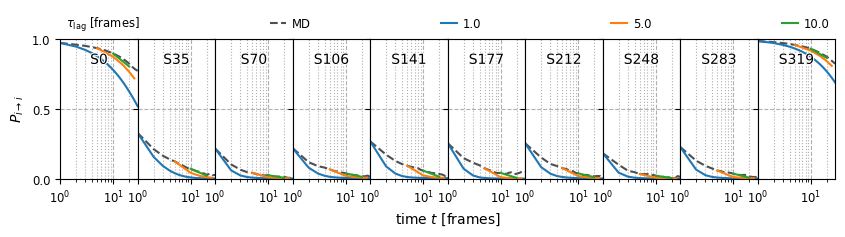

In [2]:
# Validate markov property with Chapman-Kolmogorov Test
# https://moldyn.github.io/msmhelper/tutorials/msm/#implied-timescales

n_clusters = 320

with open(f"data/clustered/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
        traj = pickle.load(f)

# change figsize
pplt.update_style(figsize=(10, 2))

lagtimes = [1, 5, 10]
tmax = 29

# estimating the CK test
ck = mh.msm.ck_test(traj, lagtimes, tmax)

# plot the results
states = [int(i) for i in np.linspace(0, 319, 10)]
# states = [0, n_clusters - 1]
_ = mh.plot.plot_ck_test(ck=ck, states=states, grid=(1, 10))

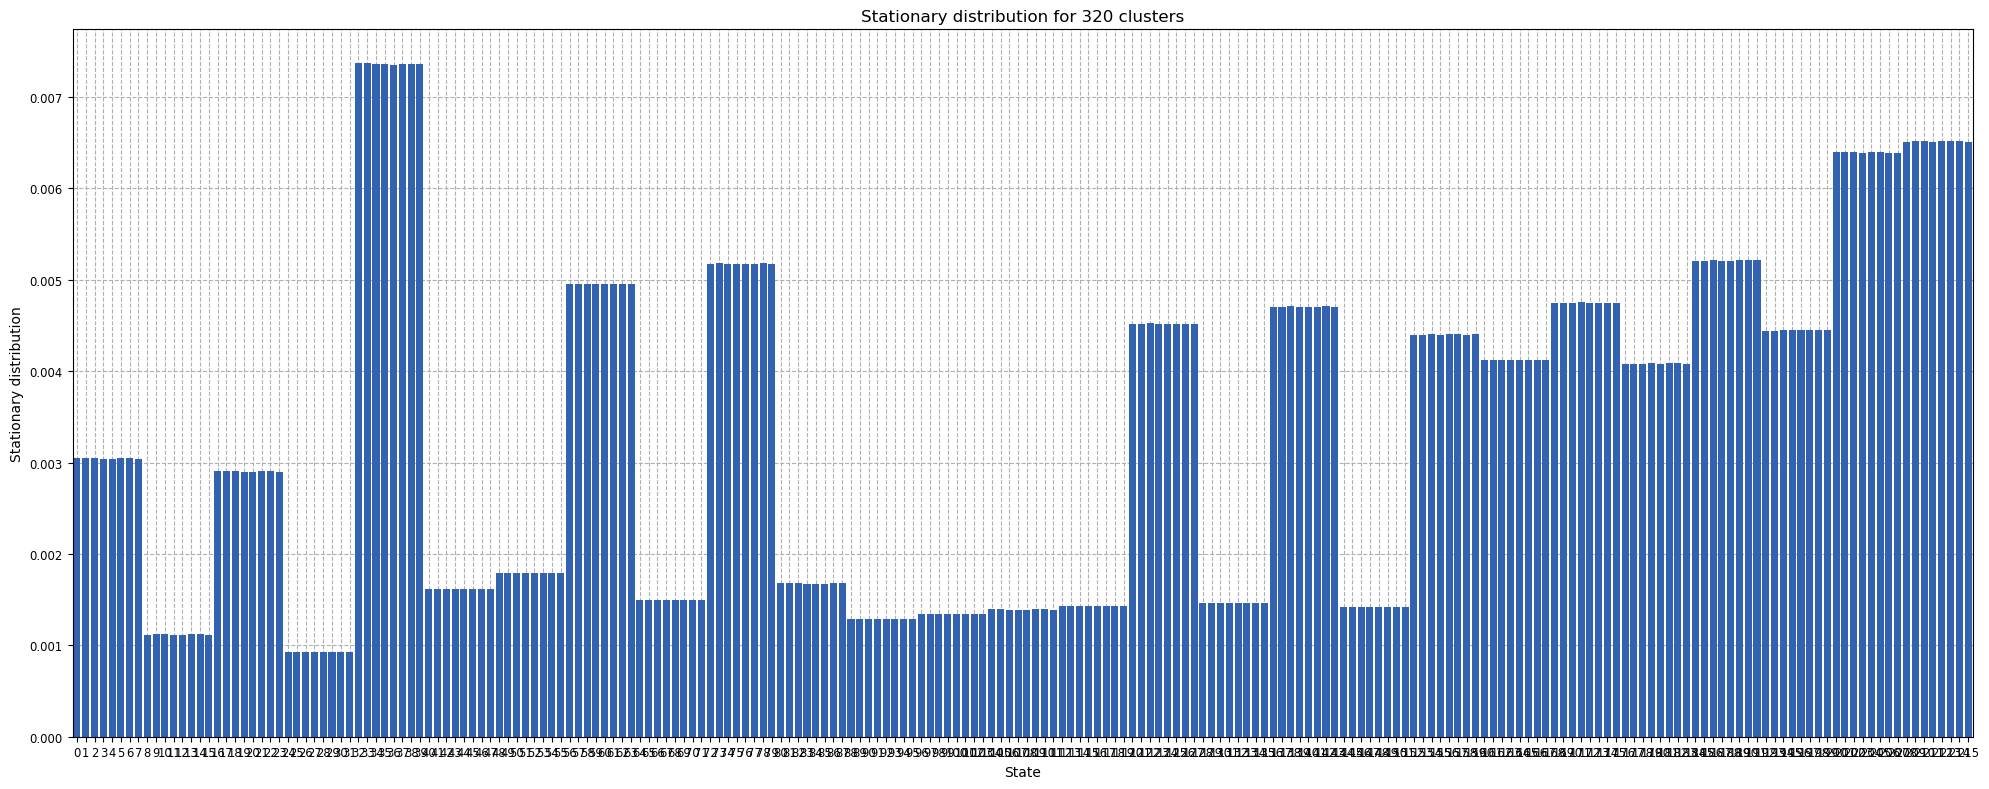

In [25]:
# Validate the stationary distribution


n_clusters = 320

with open(f"data/transition_matrices/cluster-kmeans/74pca-{n_clusters}clusters.pickle", "rb") as f:
    P = pickle.load(f)
    
with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
    pca_cluster = pickle.load(f)
    
pi = stationary_distribution(P)
pi = pca_cluster.get_inverse_stationary(pi)
pi = pi[1:-1]

plt.figure(figsize=(20, 8))
plt.bar(range(len(pi)), pi, color='pplt:blue')
plt.xlabel('State')
plt.ylabel('Stationary distribution')
plt.title(f'Stationary distribution for {n_clusters} clusters')
plt.xticks(range(len(pi)))
plt.xlim(-0.5, len(pi) - 0.5)
plt.tight_layout()
plt.show()

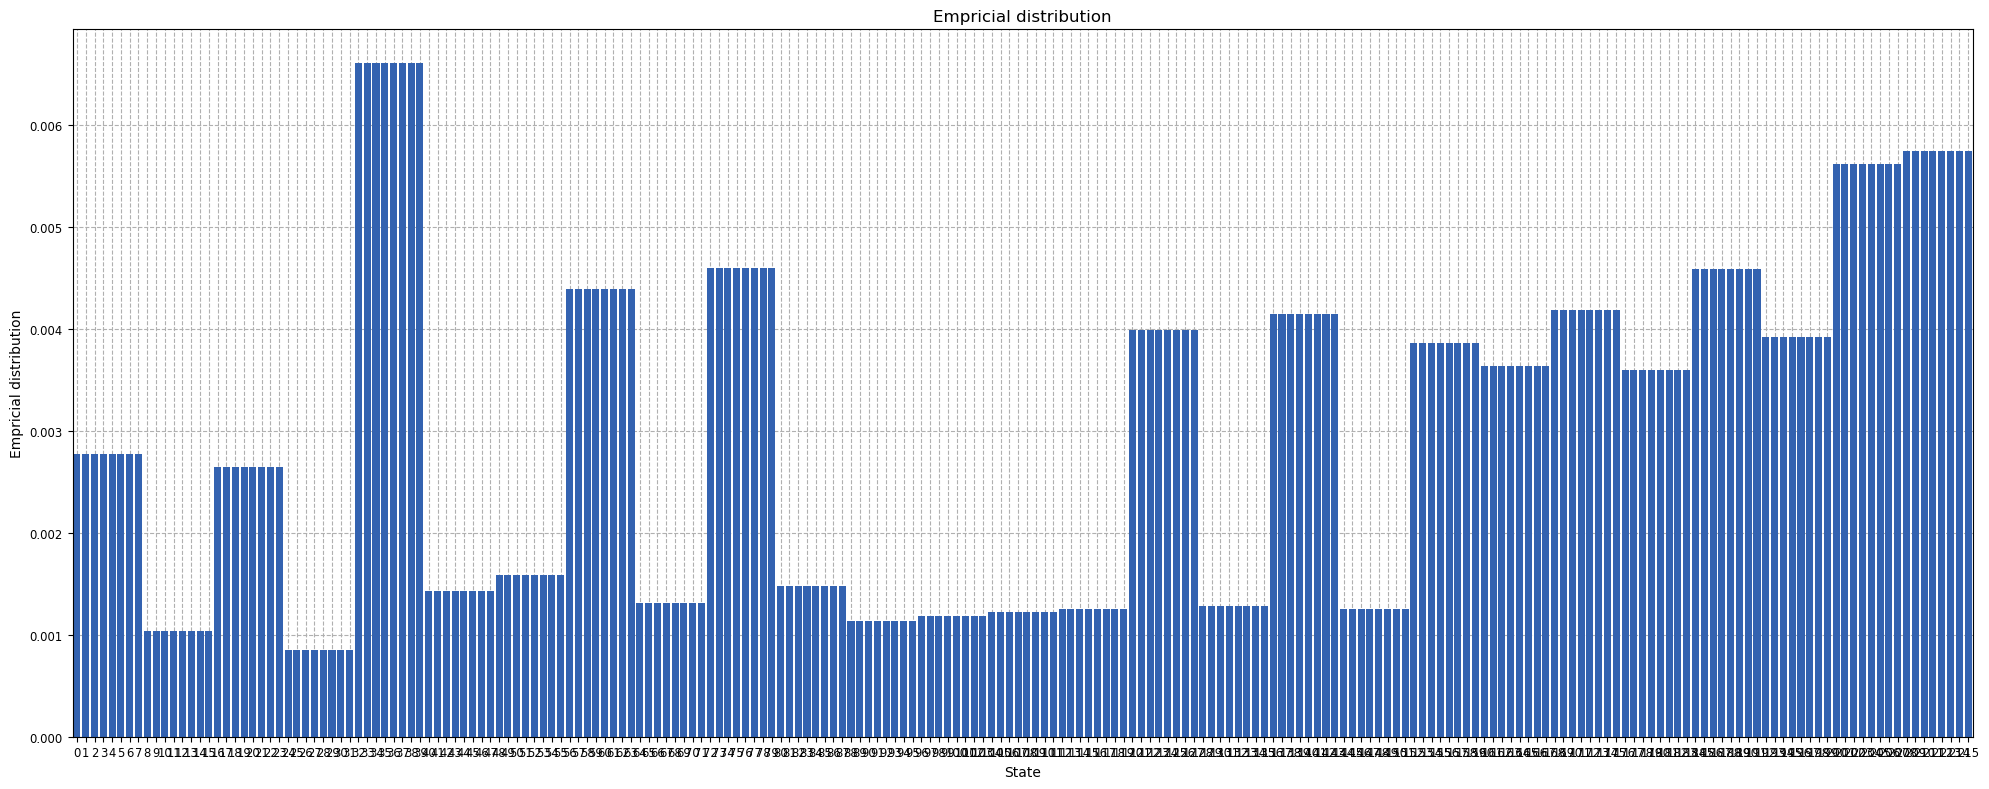

In [31]:
pi = md_empirical = get_md_empiricial_distribution("data/categorized/interactions-150-180-100ns-3k.pickle", 12500, 300)
pi = pi[1:-1]

# 8 sym
pi = pi.reshape(-1, 8)
pi = np.mean(pi, axis=1, keepdims=True)
pi = np.repeat(pi, 8, axis=1).reshape(-1)


plt.figure(figsize=(20, 8))
plt.bar(range(len(pi)), pi, color='pplt:blue')
plt.xlabel('State')
plt.ylabel('Empricial distribution')
plt.title(f'Empricial distribution')
plt.xticks(range(len(pi)))
plt.xlim(-0.5, len(pi) - 0.5)
plt.tight_layout()
plt.show()